In [1]:
import qiskit.visualization.circuit.matplotlib as matplotlib_drawer

print(matplotlib_drawer)
print(type(matplotlib_drawer))

<module 'qiskit.visualization.circuit.matplotlib' from 'e:\\Anaconda\\envs\\qiskit-env\\Lib\\site-packages\\qiskit\\visualization\\circuit\\matplotlib.py'>
<class 'module'>


In [2]:
from qiskit.visualization.circuit import matplotlib

print(matplotlib)
print(type(matplotlib))

<module 'qiskit.visualization.circuit.matplotlib' from 'e:\\Anaconda\\envs\\qiskit-env\\Lib\\site-packages\\qiskit\\visualization\\circuit\\matplotlib.py'>
<class 'module'>


# Deutsch-Jozsa Algorithm

The Deutsch-Jozsa algorithm determines whether a black-box function $f : \{0, 1\} \to \{0, 1\}$ is **constant** or **balanced** using only **one** query to the oracle — exponentially faster than any classical deterministic algorithm.

## Function Types

| Type | Definition |
|------|------------|
| **Constant** | $f(x)$ returns the same value for all inputs (always 0 or always 1) |
| **Balanced** | $f(x)$ returns 0 for exactly half the inputs and 1 for the other half |

## Circuit Overview

1. Initialise input qubit $|x\rangle = |0\rangle$ and ancilla qubit $|y\rangle = |1\rangle$  
2. Apply Hadamard gates to both qubits  
3. Apply the oracle $U_f$  
4. Apply Hadamard to the input qubit  
5. Measure the input qubit:  
   - $|0\rangle \Rightarrow$ **constant**  
   - $|1\rangle \Rightarrow$ **balanced**

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

## Oracle Definitions

We define four possible single-bit oracles implementing $U_f |x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$:

| Oracle | $f(0)$ | $f(1)$ | Type |
|--------|--------|--------|------|
| `constant_0` | 0 | 0 | Constant |
| `constant_1` | 1 | 1 | Constant |
| `balanced_identity` | 0 | 1 | Balanced |
| `balanced_negation` | 1 | 0 | Balanced |

In [4]:
# ==========================================================
# ORACLE FUNCTIONS
# ==========================================================
# Each oracle acts on a 2-qubit circuit:
#   qubit 0 = input  |x>
#   qubit 1 = ancilla |y>
# and implements  |x>|y> -> |x>|y XOR f(x)>


def oracle_constant_0(qc):
    """
    f(x) = 0 for all x  (constant)
    Action: do nothing — y XOR 0 = y.
    We add an identity (barrier) so the oracle
    is visible in the circuit diagram.

    """
    qc.barrier()
    qc.id(0)
    qc.id(1)
    qc.barrier()


def oracle_constant_1(qc):
    """
    f(x) = 1 for all x  (constant)
    Action: flip ancilla unconditionally — y XOR 1 = NOT y.
    
    """
    qc.barrier()
    qc.x(1)
    qc.barrier()


def oracle_balanced_identity(qc):
    """
    f(x) = x  (balanced)
    
    Action: CNOT — flip ancilla when x = 1.
    f(0) = 0, f(1) = 1.
    """
    qc.barrier()
    qc.cx(0, 1)
    qc.barrier()


def oracle_balanced_negation(qc):
    """
    f(x) = NOT x  (balanced)
    
    Action: flip ancilla when x = 0.
    f(0) = 1, f(1) = 0.
    """
    qc.barrier()
    qc.x(0)
    qc.cx(0, 1)
    qc.x(0)
    qc.barrier()

## Build the Deutsch-Jozsa Circuit

The function below constructs the full circuit for a given oracle.

### State evolution

$$|\psi_0\rangle = |0\rangle \otimes |1\rangle$$

$$\xrightarrow{H \otimes H} \quad |\psi_1\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

$$\xrightarrow{U_f} \quad |\psi_2\rangle = \frac{(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

$$\xrightarrow{H \otimes I} \quad |\psi_3\rangle$$

**Measurement outcome on qubit 0:**
- If $f$ is **constant**: $f(0) = f(1)$, so we measure $|0\rangle$ with certainty  
- If $f$ is **balanced**: $f(0) \neq f(1)$, so we measure $|1\rangle$ with certainty

In [5]:
def build_deutsch_jozsa_circuit(oracle_func, oracle_name="Oracle"):
    """
    Build the Deutsch-Jozsa circuit for a 1-bit function.
    
    Parameters
    ----------
    oracle_func : callable
        A function that applies the oracle Uf to a QuantumCircuit.
    oracle_name : str
        Label used for display purposes.
    
    Returns
    -------
    QuantumCircuit
        The complete Deutsch-Jozsa circuit with measurement.
    """

    # 2 qubits: q0 = input |x>, q1 = ancilla |y>
    # 1 classical bit for measuring q0
    qc = QuantumCircuit(2, 1)
    qc.name = f"Deutsch-Jozsa ({oracle_name})"

    # ----------------------------------------------------------
    # Step 1: Initialise ancilla to |1>
    # ----------------------------------------------------------
    qc.x(1)

    # ----------------------------------------------------------
    # Step 2: Apply Hadamard to both qubits
    #   |0> -> (|0> + |1>) / sqrt(2)
    #   |1> -> (|0> - |1>) / sqrt(2)
    # ----------------------------------------------------------
    qc.h(0)
    qc.h(1)

    # ----------------------------------------------------------
    # Step 3: Apply oracle Uf
    #   |x>|y> -> |x>|y XOR f(x)>
    #   With ancilla in |-> state, this produces phase kickback:
    #   |x>|-> -> (-1)^f(x) |x>|->
    # ----------------------------------------------------------
    oracle_func(qc)

    # ----------------------------------------------------------
    # Step 4: Apply Hadamard to input qubit (inverse Hadamard)
    #   Maps the phase information back to computational basis
    # ----------------------------------------------------------
    qc.h(0)

    # ----------------------------------------------------------
    # Step 5: Measure input qubit
    #   |0> => f is CONSTANT
    #   |1> => f is BALANCED
    # ----------------------------------------------------------
    qc.measure(0, 0)

    return qc

## Run All Four Oracles

We test each oracle on the AerSimulator and verify the algorithm correctly classifies them.

In [6]:
# ==========================================================
# CONFIGURATION
# ==========================================================

SHOTS = 1024

oracles = [
    (oracle_constant_0,        "Constant-0",        "constant"),
    (oracle_constant_1,        "Constant-1",        "constant"),
    (oracle_balanced_identity, "Balanced-Identity", "balanced"),
    (oracle_balanced_negation, "Balanced-Negation", "balanced"),
]


# ==========================================================
# SIMULATE EACH ORACLE
# ==========================================================

simulator = AerSimulator()
results   = []

for oracle_func, name, expected_type in oracles:

    # Build circuit
    qc = build_deutsch_jozsa_circuit(oracle_func, name)

    # Transpile for the simulator
    transpiled = transpile(
        qc,
        simulator,
        optimization_level=1
    )

    # Execute
    job    = simulator.run(transpiled, shots=SHOTS)
    result = job.result()
    counts = result.get_counts()

    # Determine outcome
    if "1" in counts and counts.get("1", 0) > counts.get("0", 0):
        measured_type = "balanced"
    else:
        measured_type = "constant"

    match = "PASS" if measured_type == expected_type else "FAIL"

    results.append({
        "name":          name,
        "counts":        counts,
        "expected_type": expected_type,
        "measured_type": measured_type,
        "match":         match,
        "circuit":       qc,
    })


# ==========================================================
# PRINT SUMMARY TABLE
# ==========================================================

print(f"{'Oracle':<25} {'Counts':<20} {'Expected':<12} {'Measured':<12} {'Result'}")
print("=" * 80)

for r in results:
    print(
        f"{r['name']:<25} "
        f"{str(r['counts']):<20} "
        f"{r['expected_type']:<12} "
        f"{r['measured_type']:<12} "
        f"{r['match']}"
    )

Oracle                    Counts               Expected     Measured     Result
Constant-0                {'0': 1024}          constant     constant     PASS
Constant-1                {'0': 1024}          constant     constant     PASS
Balanced-Identity         {'1': 1024}          balanced     balanced     PASS
Balanced-Negation         {'1': 1024}          balanced     balanced     PASS


## Circuit Diagrams

Visualise each of the four Deutsch-Jozsa circuits.

In [7]:
import sys
print(sys.executable)

e:\Anaconda\envs\qiskit-env\python.exe


In [8]:
import sys
!{sys.executable} -m pip install pylatexenc

In [9]:
import pylatexenc
print("pylatexenc installed successfully")

pylatexenc installed successfully



  Constant-0  —  CONSTANT



TypeError: 'module' object is not callable

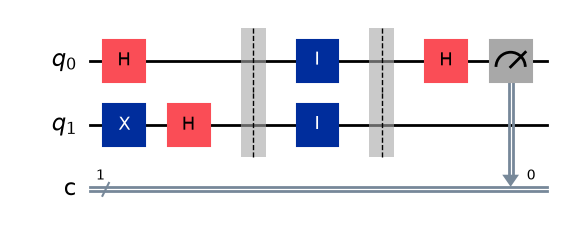

In [10]:
from IPython import display
for r in results:
    print(f"\n{'='*60}")
    print(f"  {r['name']}  —  {r['expected_type'].upper()}")
    print(f"{'='*60}\n")
    display(r["circuit"].draw("mpl"))

## Measurement Histograms

Bar plots of the measurement outcomes for each oracle, confirming the algorithm's correctness.

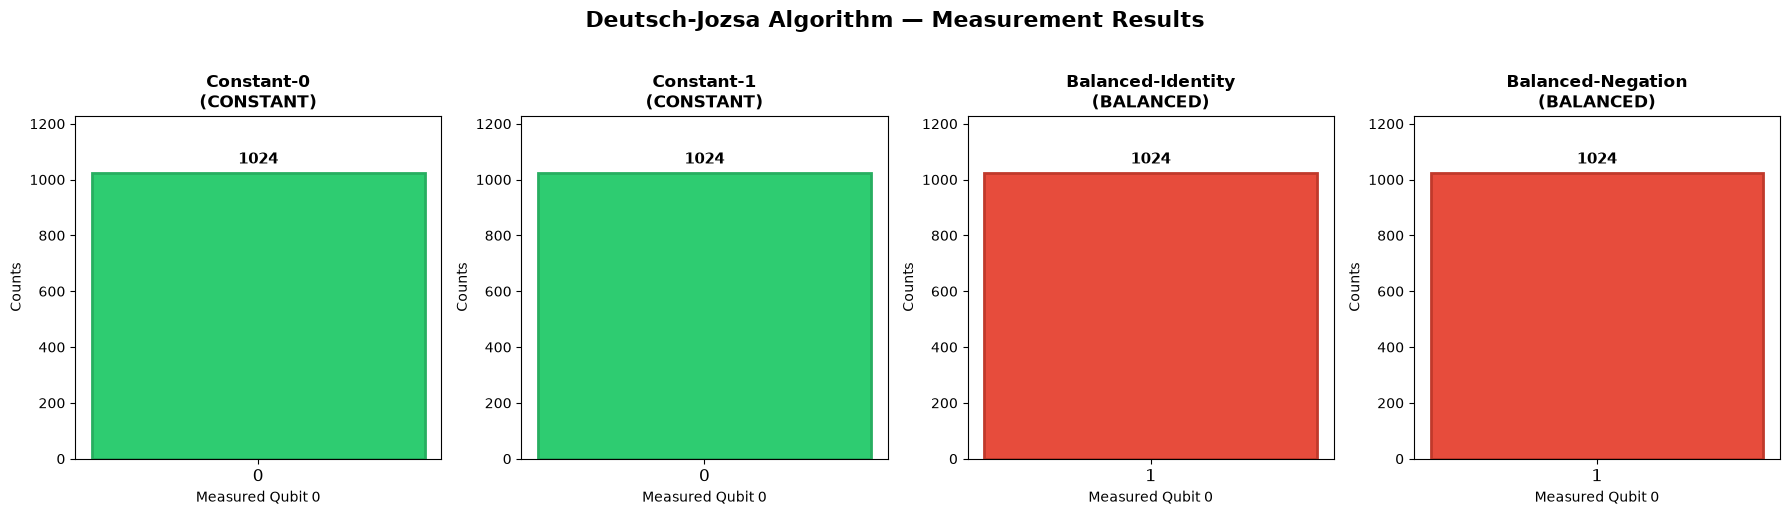

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

colors_map = {
    "constant": ["#2ecc71", "#27ae60"],
    "balanced": ["#e74c3c", "#c0392b"],
}

for ax, r in zip(axes, results):

    states = sorted(r["counts"].keys())
    values = [r["counts"][s] for s in states]
    colors = colors_map[r["measured_type"]]

    bars = ax.bar(
        states, values,
        color=colors[0],
        edgecolor=colors[1],
        linewidth=2,
        width=0.5
    )

    # Annotate bar values
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + SHOTS * 0.02,
            str(val),
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )

    ax.set_title(
        f"{r['name']}\n({r['measured_type'].upper()})",
        fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Measured Qubit 0", fontsize=10)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_ylim(0, SHOTS * 1.2)
    ax.set_xticks([0, 1] if len(states) == 2 else range(len(states)))
    ax.set_xticklabels(states, fontsize=12)

fig.suptitle(
    "Deutsch-Jozsa Algorithm — Measurement Results",
    fontsize=16, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

## Detailed Step-by-Step: Balanced-Identity Oracle

Let's trace through the state transformations for the `balanced_identity` oracle ($f(x) = x$).

In [ ]:
from qiskit.quantum_info import Statevector
import numpy as np


print("Deutsch-Jozsa Step-by-Step  (Oracle: Balanced-Identity, f(x) = x)")
print("=" * 70)


# ----------------------------------------------------------
# Step 0: Initial state |0>|1>
# ----------------------------------------------------------

qc_step = QuantumCircuit(2)
qc_step.x(1)

sv = Statevector.from_instruction(qc_step)
print(f"\nStep 0  |ψ₀⟩ = |0⟩|1⟩")
print(f"  Statevector: {sv}")


# ----------------------------------------------------------
# Step 1: After H ⊗ H
# ----------------------------------------------------------

qc_step.h(0)
qc_step.h(1)

sv = Statevector.from_instruction(qc_step)
print(f"\nStep 1  After H⊗H")
print(f"  |ψ₁⟩ = (|0⟩+|1⟩)/√2 ⊗ (|0⟩-|1⟩)/√2")
print(f"  Statevector: {sv}")


# ----------------------------------------------------------
# Step 2: After Oracle (CNOT for balanced-identity)
# ----------------------------------------------------------

qc_step.cx(0, 1)

sv = Statevector.from_instruction(qc_step)
print(f"\nStep 2  After Oracle Uf (CNOT)")
print(f"  |ψ₂⟩ = (-1)^f(0)|0⟩|-> + (-1)^f(1)|1⟩|->")
print(f"       = |0⟩|-> - |1⟩|->")
print(f"  Statevector: {sv}")


# ----------------------------------------------------------
# Step 3: After H on qubit 0 (inverse Hadamard)
# ----------------------------------------------------------

qc_step.h(0)

sv = Statevector.from_instruction(qc_step)
print(f"\nStep 3  After H on qubit 0")
print(f"  |ψ₃⟩ = |1⟩|->   (balanced ⇒ measure |1⟩)")
print(f"  Statevector: {sv}")


# ----------------------------------------------------------
# Probabilities
# ----------------------------------------------------------

probs = sv.probabilities_dict()
print(f"\nMeasurement probabilities: {probs}")
print(f"\n→ Qubit 0 is |1⟩ with 100% probability ⇒ function is BALANCED  ✓")
print("=" * 70)

Deutsch-Jozsa Step-by-Step  (Oracle: Balanced-Identity, f(x) = x)

Step 0  |ψ₀⟩ = |0⟩|1⟩
  Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))

Step 1  After H⊗H
  |ψ₁⟩ = (|0⟩+|1⟩)/√2 ⊗ (|0⟩-|1⟩)/√2
  Statevector: Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
            dims=(2, 2))

Step 2  After Oracle Uf (CNOT)
  |ψ₂⟩ = (-1)^f(0)|0⟩|-> + (-1)^f(1)|1⟩|->
       = |0⟩|-> - |1⟩|->
  Statevector: Statevector([ 0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j],
            dims=(2, 2))

Step 3  After H on qubit 0
  |ψ₃⟩ = |1⟩|->   (balanced ⇒ measure |1⟩)
  Statevector: Statevector([ 2.29934717e-17+0.j,  7.07106781e-01+0.j, -2.29934717e-17+0.j,
             -7.07106781e-01+0.j],
            dims=(2, 2))

Measurement probabilities: {np.str_('00'): np.float64(5.286997409534849e-34), np.str_('01'): np.float64(0.4999999999999998), np.str_('10'): np.float64(5.286997409534849e-34), np.str_('11'): np.float64(0.4999999999999998)}

→ Qubit 0 is |1⟩ with 100% probabil

## Generalised n-Qubit Deutsch-Jozsa

The algorithm naturally extends to $n$-bit inputs. A function $f: \{0,1\}^n \to \{0,1\}$ is either constant or balanced, and the Deutsch-Jozsa algorithm determines which in a **single oracle query**.

Below we implement the generalised version for $n$ input qubits.

In [11]:
from IPython.display import display


In [ ]:
def build_generalised_dj(n, oracle_type="balanced"):
    """
    Build a generalised n-qubit Deutsch-Jozsa circuit.
    
    Parameters
    ----------
    n : int
        Number of input qubits.
    oracle_type : str
        'constant' or 'balanced'.
    
    Returns
    -------
    QuantumCircuit
    
    """

    # n input qubits + 1 ancilla qubit
    # n classical bits for measuring input qubits
    qc = QuantumCircuit(n + 1, n)
    qc.name = f"DJ-{n}qubit ({oracle_type})"

    # Initialise ancilla to |1>
    qc.x(n)

    # Apply H to all qubits
    qc.h(range(n + 1))

    # Oracle
    qc.barrier()

    if oracle_type == "constant":
        # f(x) = 0 for all x => do nothing
        # (could also do f(x) = 1 by adding qc.x(n))
        pass
    elif oracle_type == "balanced":
        # f(x) = x_0 XOR x_1 XOR ... XOR x_{n-1}
        # Implement with CNOT from each input qubit to ancilla
        for i in range(n):
            qc.cx(i, n)
    else:
        raise ValueError(f"Unknown oracle type: {oracle_type}")

    qc.barrier()

    # Apply H to input qubits
    qc.h(range(n))

    # Measure input qubits
    qc.measure(range(n), range(n))

    return qc


# ==========================================================
# RUN GENERALISED DJ FOR n = 4
# ==========================================================

N_INPUT_QUBITS = 4
SHOTS_GEN      = 1024
simulator      = AerSimulator()

print(f"Generalised Deutsch-Jozsa Algorithm  (n = {N_INPUT_QUBITS} input qubits)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, otype in enumerate(["constant", "balanced"]):

    qc = build_generalised_dj(N_INPUT_QUBITS, otype)

    transpiled = transpile(qc, simulator, optimization_level=1)
    job        = simulator.run(transpiled, shots=SHOTS_GEN)
    counts     = job.result().get_counts()

    # For n-qubit DJ: all zeros => constant, anything else => balanced
    all_zeros = "0" * N_INPUT_QUBITS

    if all_zeros in counts and counts[all_zeros] == SHOTS_GEN:
        detected = "constant"
    else:
        detected = "balanced"

    match = "PASS" if detected == otype else "FAIL"

    print(f"\n  Oracle: {otype:<12}  Counts: {counts}")
    print(f"  Detected: {detected:<12}  Result: {match}")

    # Display circuit
    display(qc.draw("mpl"))

    # Plot histogram
    ax = axes[idx]
    sorted_states = sorted(counts.keys())
    sorted_values = [counts[s] for s in sorted_states]

    colour = "#2ecc71" if otype == "constant" else "#e74c3c"
    ax.bar(
        sorted_states, sorted_values,
        color=colour, edgecolor="#2c3e50",
        linewidth=1.5
    )
    ax.set_title(
        f"{otype.upper()} Oracle",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Measured State", fontsize=10)
    ax.set_ylabel("Counts", fontsize=10)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(
    f"Generalised Deutsch-Jozsa  (n = {N_INPUT_QUBITS})",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("All oracles classified correctly with a single query!")